# Simulation of the Polarization Ellipse of Electromagnetic Waves

This interactive notebook aims to study and visualize the polarization state of a monochromatic electromagnetic wave.

From a classical perspective, the polarization state of a transverse wave is completely determined by the curve described by the tip of the electric field vector ($\vec{E}$) in a plane perpendicular to the direction of propagation (by convention, the $z=0$ plane).

Suppose an electromagnetic wave propagates along the $Z$-axis. The electric field can be decomposed into two orthogonal components along the $X$ and $Y$ axes, which oscillate with the same angular frequency ($\omega$) but with amplitudes ($A_1$, $A_2$) and phases that, in general, are different. Evaluating at $z=0$, the parametric equations of the electric field are:

$$E_x(t)=A_1\cos(\omega t)$$
$$E_y(t)=A_2\cos(\omega t+\delta)$$

Where $\delta$ represents the relative phase difference between both components ($\delta=\delta_y-\delta_x$).

By eliminating the time dependence ($\omega t$) from the above equations, we obtain the geometric locus described by the tip of the $\vec{E}$ vector, known as the **general equation of the polarization ellipse**:

$$\left(\frac{E_x}{A_1}\right)^2+\left(\frac{E_y}{A_2}\right)^2-2\frac{E_x}{A_1}\frac{E_y}{A_2}\cos\delta=\sin^2\delta$$

This simulation allows for interactive modification of the fundamental wave parameters ($A_1$, $A_2$, and $\delta$) to analyze the two main characteristics of the resulting ellipse:

1. **Major axis inclination ($\varphi$):** The angle the major axis of the ellipse makes with the $X$-axis, which satisfies the relation $\tan(2\varphi)=\tan(2\alpha)\cos\delta$, where $\tan\alpha=A_2/A_1$.
2. **Sense of rotation (Helicity):** Determined by the sign of $\sin\delta$. A value of $\sin\delta>0$ ($0<\delta<\pi$) implies a clockwise rotation of the electric field (**right-handed polarization**), while $\sin\delta<0$ ($\pi<\delta<2\pi$) implies a counter-clockwise rotation (**left-handed polarization**).

Through the interactive controls, the user can visually verify how elliptical polarization degenerates into the special cases of **linear polarization** (when $\delta=m\pi$) and **circular polarization** (when $A_1=A_2$ and $\delta=(2m+1)\pi/2$).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact
import ipywidgets as widgets

In [2]:
def simulate_polarization(delta_deg, A1=1.0, A2=1.0):
    
    delta = np.radians(delta_deg)
    
    wt = np.linspace(0, 2 * np.pi, 500)
    
    Ex = A1 * np.cos(wt)
    Ey = A2 * np.cos(wt + delta)
    
    alpha = np.arctan2(A2, A1)
    
    tan_2phi = np.tan(2 * alpha) * np.cos(delta)
    phi = 0.5 * np.arctan(tan_2phi)
    
    if A1 < A2 and np.cos(delta) < 0:
        phi += np.pi / 2
    elif A1 < A2 and np.cos(delta) > 0:
        phi -= np.pi / 2
        
    phi_deg = np.degrees(phi)
    
    delta_mod = delta % (2 * np.pi)
    sin_delta = np.sin(delta_mod)
    
    if abs(sin_delta) < 1e-10:
        rotation_sense = "Linear (No rotation)"
    elif sin_delta > 0:
        rotation_sense = "Right-handed (Clockwise)"
    else:
        rotation_sense = "Left-handed (Counter-clockwise)"
        
    # --- PLOTTING ---
    plt.figure(figsize=(7, 7))
    plt.plot(Ex, Ey, label='Tip trajectory of $\\vec{E}$', color='blue', linewidth=2)
    
    if abs(sin_delta) >= 1e-10:
        for i in [100, 350]:
            plt.annotate('', 
                         xy=(Ex[i+5], Ey[i+5]),
                         xytext=(Ex[i], Ey[i]),
                         arrowprops=dict(arrowstyle="-|>", color="blue", lw=2, mutation_scale=20))
            
    plt.plot([-A1, A1, A1, -A1, -A1], [-A2, -A2, A2, A2, -A2], 'r--', alpha=0.3, label='Bounding box $2A_1 \\times 2A_2$')
    
    # Plot configurations
    plt.title(f"Polarization Ellipse\n$\\delta$ = {delta_deg}º | Inclination ($\\varphi$) = {phi_deg:.2f}º\nSense: {rotation_sense}")
    
    axis_limit = max(A1, A2) + 0.5
    
    plt.xlim(-axis_limit, axis_limit)
    plt.ylim(-axis_limit, axis_limit)
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(color='gray', linestyle=':', linewidth=0.7)
    plt.xlabel('$E_x$ Component', fontsize=12)
    plt.ylabel('$E_y$ Component', fontsize=12)
    plt.legend(loc='upper right')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

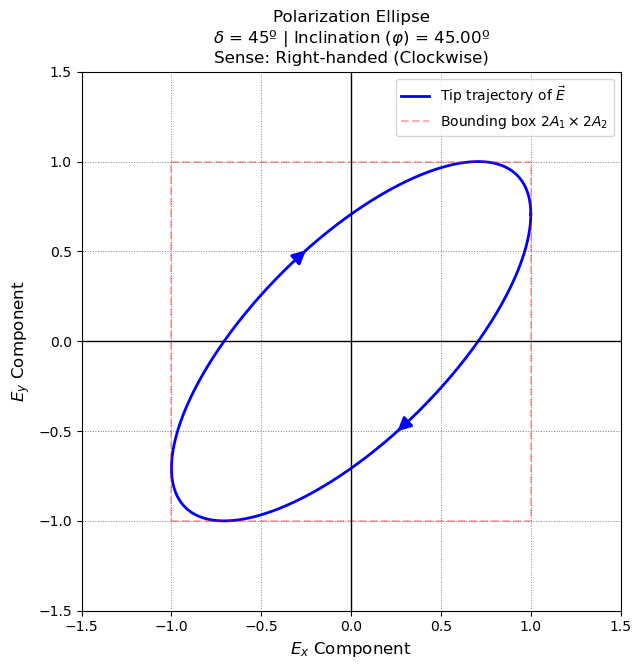

In [3]:
# Simply change the numbers here to test the function:
# delta_deg is the phase difference in degrees, A1 and A2 are the amplitudes
simulate_polarization(delta_deg=45, A1=1.0, A2=1.0)

#### Physical Conclusions

Through this interactive simulation, we can visually confirm the extreme cases of the general polarization ellipse depending on the phase difference ($\delta$) and amplitudes ($A_1, A_2$):

* **Linear Polarization:** Occurs when the phase difference is a multiple of $\pi$ ($\delta = 0, \pi, 2\pi...$). The ellipse degenerates into a straight line with a slope determined by the ratio $A_2/A_1$.
* **Circular Polarization:** The most restrictive case. It requires strictly equal amplitudes ($A_1 = A_2$) and a phase difference of exactly an odd multiple of $\pi/2$ ($\delta = 90^\circ, 270^\circ$). The bounding box becomes a perfect square.
* **Helicity (Handedness):** The simulation clearly demonstrates that the sign of $\sin(\delta)$ governs the rotation direction of the electric field vector. A phase delay in the $y$-component ($0^\circ < \delta < 180^\circ$) produces a right-handed rotation, while an advance ($180^\circ < \delta < 360^\circ$) results in a left-handed rotation.